Unique node_type labels: [0 4 5 6]
Selected label 5: 17 nodes


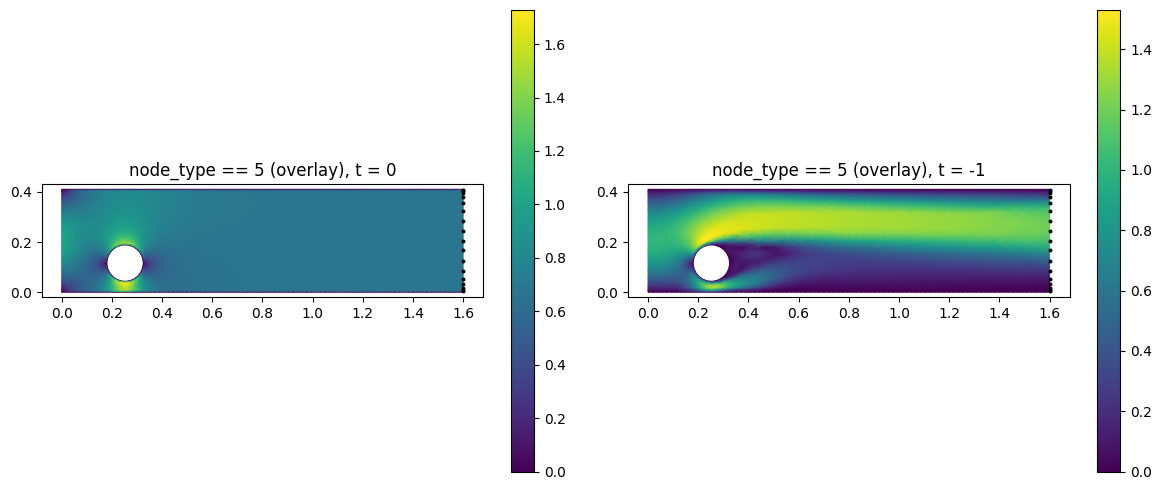

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# ----------- CONFIG -------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/train.h5"
sample_id = "sample_000034"
t_vis = -1                 # later time step to show background field (optional)
target_label = 5           # <-- change this to test different node_type labels
show_background = True      # set False to only plot the selected nodes
# --------------------------------

with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]              # (N,2)
    cells = g["cells"][:]          # (C,3)
    vel = g["vel"][:]              # (T,N,2)
    node_type = g["node_type"][:]  # (N,)

# Triangulation for background
triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)

# Background scalar field (velocity magnitude)
vel_mag_0 = np.linalg.norm(vel[0], axis=1)
vel_mag_t = np.linalg.norm(vel[t_vis], axis=1)

# Mask for selected node_type
mask = (node_type == target_label)
xy_sel = pos[mask]

print("Unique node_type labels:", np.unique(node_type))
print(f"Selected label {target_label}: {mask.sum()} nodes")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, field, title in [
    (axes[0], vel_mag_0, "t = 0"),
    (axes[1], vel_mag_t, f"t = {t_vis}"),
]:
    if show_background:
        im = ax.tripcolor(triang, field, shading="gouraud")
        plt.colorbar(im, ax=ax)

    # Plot ONLY the selected nodes
    ax.scatter(
        xy_sel[:, 0], xy_sel[:, 1],
        s=8,
        marker="o",
        linewidths=0.0,
        color = "black"
    )

    ax.set_title(f"node_type == {target_label} (overlay), {title}")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

Input channels (vel + node_type one-hot): 6
conv0 L: 1.600000023841858 0.4099999964237213
conv4 L: 1.600000023841858 0.4099999964237213
MSE: 0.0006825211


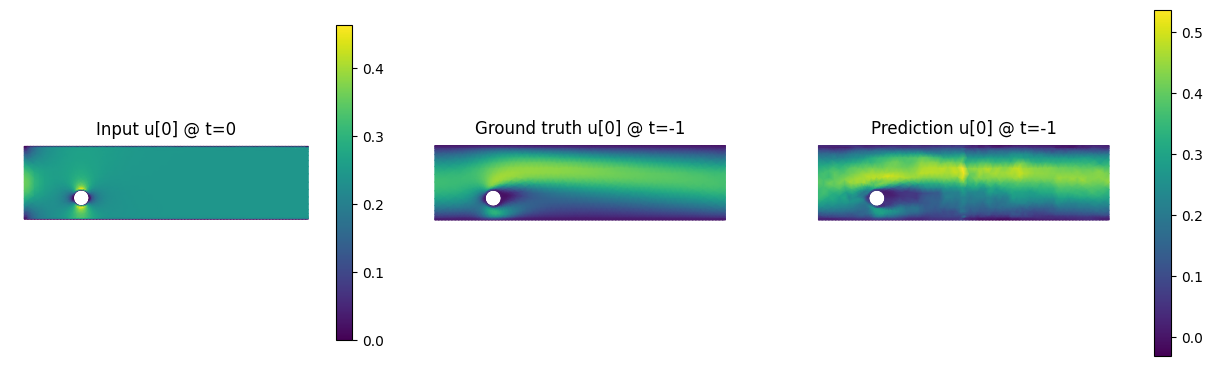

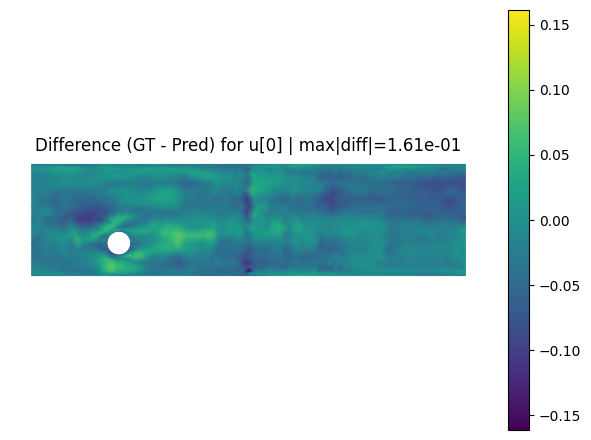

In [4]:
# ============================================================
# Evaluate trained Geo-FNO on cylinder_flow H5 (velocity one-step)
# - Loads FNO2d + IPHI weights
# - Selects one sample and one velocity component (ux or uy)
# - Plots 1x3: input vel component at t_in, GT at t_out, prediction at t_out
# - Then plots per-node difference (GT - pred) on the mesh
#
# IMPORTANT:
# - For Geo-FNO, values live on an irregular mesh, so we use tripcolor/scatter.
# - "per pixel" here means "per node" (mesh point).
# ============================================================

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import torch
import torch.nn.functional as F
from geo_FNO_def import *

# ----------------------------
# Paths / config
# ----------------------------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"   # or train.h5
sample_id = "sample_000091"   # change to any sample key that exists
t_in = 0
t_out = -1
component = 0                # 0 -> u_x, 1 -> u_y
boundary_label = 6
band_frac = 0.06

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ---- model hyperparams MUST match training ----
modes = 20
width = 32
s1 = 80
s2 = 40

# ---- checkpoints (edit to where you saved) ----
FNO_CKPT  = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_1_with_node_type_fno.pt"
IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_1_with_node_type_iphi.pt"

# Must match one-hot mapping used during training
NODE_TYPE_VALUES = [0, 4, 5, 6]
NODE_TYPE_TO_IDX = {v: i for i, v in enumerate(NODE_TYPE_VALUES)}


# ----------------------------
# Cylinder fit utilities (same as training)
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a*a + b_*b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)

def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r

def get_global_L_from_h5(h5_path: str, key: str | None = None):
    import h5py, numpy as np
    with h5py.File(h5_path, "r") as f:
        if key is None:
            keys = sorted([k for k in f.keys() if k.startswith("sample_")])
            key = keys[0]
        pos = f[key]["pos"][:]  # (N,2)
    L1 = float(pos[:, 0].max() - pos[:, 0].min())
    L2 = float(pos[:, 1].max() - pos[:, 1].min())
    return [L1, L2], key

# ----------------------------
# Load one sample from H5
# ----------------------------
with h5py.File(H5_PATH, "r") as f:
    g = f[sample_id]
    pos = g["pos"][:]           # (N,2)
    cells = g["cells"][:]       # (C,3)
    node_type = g["node_type"][:]# (N,)
    vel = g["vel"][:]           # (T,N,2)

u_vel_in = vel[t_in].astype(np.float32)            # (N,2)
u_out_np = vel[t_out].astype(np.float32)           # (N,2)

node_feat = np.zeros((node_type.shape[0], len(NODE_TYPE_VALUES)), dtype=np.float32)
for i, nt in enumerate(node_type.astype(np.int32)):
    node_feat[i, NODE_TYPE_TO_IDX[int(nt)]] = 1.0

u_in_np = np.concatenate([u_vel_in, node_feat], axis=-1)  # (N, 2 + K)

# geometry code (42,)
xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=boundary_label, band_frac=band_frac)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r

# ----------------------------
# Load model + iphi (MUST match your definitions)
# ----------------------------
# Assumes FNO2d and IPHI classes are already defined/imported exactly as in training.
L_global, _ = get_global_L_from_h5(H5_PATH)

in_channels = 2 + len(NODE_TYPE_VALUES)
model = FNO2d(modes, modes, width,
             in_channels=in_channels, out_channels=2,
             is_mesh=False, s1=s1, s2=s2,
             L=L_global).to(device)
print("Input channels (vel + node_type one-hot):", in_channels)

model_iphi = IPHI(width=32, device=str(device)).to(device)

print("conv0 L:", model.conv0.L1, model.conv0.L2)
print("conv4 L:", model.conv4.L1, model.conv4.L2)

model.load_state_dict(torch.load(FNO_CKPT, map_location=device), strict=False)
model_iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device), strict=False)
model.eval()
model_iphi.eval()

# ----------------------------
# Inference
# ----------------------------
pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)        # (1,N,2)
u_in_t = torch.from_numpy(u_in_np.astype(np.float32)).unsqueeze(0).to(device)   # (1,N,2+K)
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)                       # (1,42)

with torch.no_grad():
    pred_t = model(u_in_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=model_iphi)  # (1,N,2)

pred_np = pred_t[0].cpu().numpy()  # (N,2)

mse = np.mean((pred_np - u_out_np)**2)
print("MSE:", mse)

# pick component to plot
inp_field  = u_vel_in[:, component]
gt_field   = u_out_np[:, component]
pred_field = pred_np[:, component]
diff_field = gt_field - pred_field

# ----------------------------
# Plotting helper: same color scale for GT/pred, symmetric for diff
# ----------------------------
triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)

common_min = float(min(gt_field.min(), pred_field.min()))
common_max = float(max(gt_field.max(), pred_field.max()))
diff_abs = float(np.max(np.abs(diff_field)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Input at t_in (own scale is fine; but you can also share scale if you want)
im0 = axes[0].tripcolor(triang, inp_field, shading="gouraud")
axes[0].set_title(f"Input u[{component}] @ t={t_in}")
axes[0].set_aspect("equal")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Ground truth at t_out (shared scale with pred)
im1 = axes[1].tripcolor(triang, gt_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[1].set_title(f"Ground truth u[{component}] @ t={t_out}")
axes[1].set_aspect("equal")
axes[1].axis("off")

im2 = axes[2].tripcolor(triang, pred_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[2].set_title(f"Prediction u[{component}] @ t={t_out}")
axes[2].set_aspect("equal")
axes[2].axis("off")

fig.colorbar(im1, ax=axes[1:], fraction=0.025, pad=0.04)
#plt.tight_layout()
plt.show()

# Difference plot
plt.figure(figsize=(6, 4.5))
imd = plt.tripcolor(triang, diff_field, shading="gouraud", vmin=-diff_abs, vmax=diff_abs)
plt.gca().set_aspect("equal")
plt.title(f"Difference (GT - Pred) for u[{component}] | max|diff|={diff_abs:.2e}")
plt.axis("off")
plt.colorbar(imd, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Using L_global from sample_000000 : [1.600000023841858, 0.4099999964237213]
Input channels (vel + node_type one-hot): 6
conv0 L: 1.600000023841858 0.4099999964237213
conv4 L: 1.600000023841858 0.4099999964237213
Num samples: 100
[  50/100] current=sample_000049 mse=7.857e-03 best=6.900e-04 (sample_000007)
[ 100/100] current=sample_000099 mse=1.103e-03 best=6.825e-04 (sample_000091)

Top 10 best samples:
sample_000091 6.825211e-04
sample_000007 6.899516e-04
sample_000023 9.057516e-04
sample_000074 9.725486e-04
sample_000029 1.066879e-03
sample_000099 1.102584e-03
sample_000062 1.233518e-03
sample_000098 1.258883e-03
sample_000040 1.295150e-03
sample_000034 1.345037e-03

Worst 5 samples:
sample_000068 2.491181e-02
sample_000006 2.669959e-02
sample_000075 2.841347e-02
sample_000012 3.117264e-02
sample_000038 3.145987e-02

BEST sample: sample_000091  MSE=6.825211e-04


/tmp/ipykernel_1164327/3925573812.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


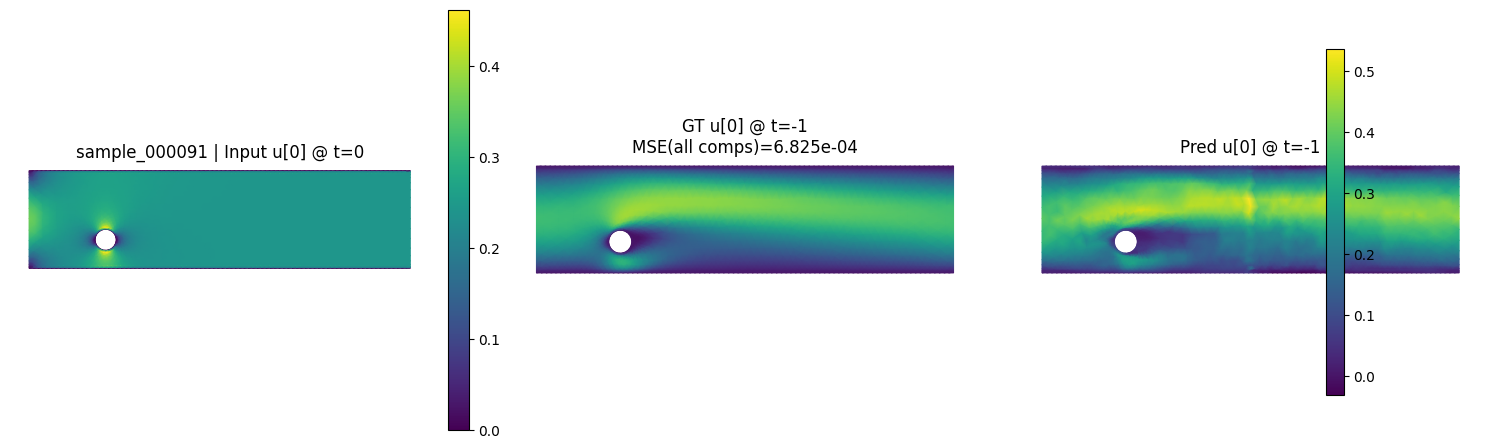

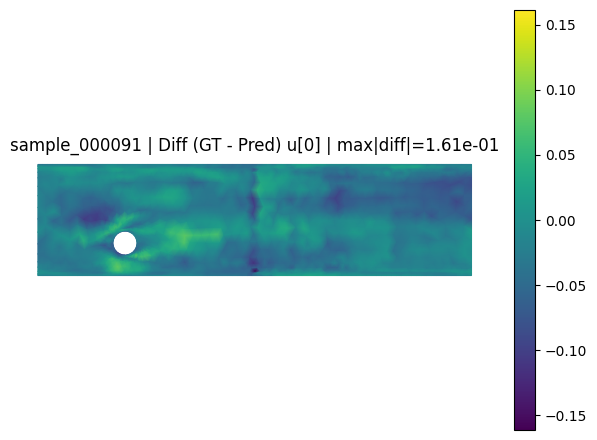

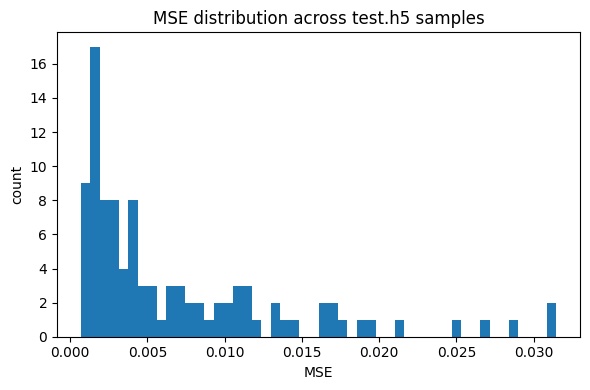

In [3]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as tri

from geo_FNO_def import FNO2d, IPHI, get_global_L_from_h5

# ----------------------------
# Config
# ----------------------------
H5_PATH   = "/scratch/mnhagen/datasets/incompressible_euler/test.h5"
t_in      = 0
t_out     = -1
component = 0   # for plots only: 0=u_x, 1=u_y

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# MUST match training
modes = 20
width = 32
s1 = 80
s2 = 40

#FNO_CKPT  = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_100samples_fno.pt"
#IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_100samples_iphi.pt"

# Must match one-hot mapping used during training
NODE_TYPE_VALUES = [0, 4, 5, 6]
NODE_TYPE_TO_IDX = {v: i for i, v in enumerate(NODE_TYPE_VALUES)}


# ----------------------------
# Geometry utilities (same as your eval code)
# ----------------------------
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a*a + b_*b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)

def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray,
                                  boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]
    xc, yc, r = fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])
    return xc, yc, r


# ----------------------------
# Load model
# ----------------------------
L_global, key_used = get_global_L_from_h5(H5_PATH)
print("Using L_global from", key_used, ":", L_global)

in_channels = 2 + len(NODE_TYPE_VALUES)
model = FNO2d(
    modes, modes, width,
    in_channels=in_channels, out_channels=2,
    is_mesh=False, s1=s1, s2=s2,
    L=L_global
).to(device)
print("Input channels (vel + node_type one-hot):", in_channels)

model_iphi = IPHI(width=32, device=str(device)).to(device)

model.load_state_dict(torch.load(FNO_CKPT, map_location=device))
model_iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device))
model.eval()
model_iphi.eval()

print("conv0 L:", model.conv0.L1, model.conv0.L2)
print("conv4 L:", model.conv4.L1, model.conv4.L2)

# ----------------------------
# Evaluate all samples
# ----------------------------
boundary_label = 6
band_frac = 0.06

sample_losses = []
best = {"key": None, "loss": float("inf"), "pos": None, "cells": None,
        "u_in_vel": None, "u_out": None, "pred": None}

with h5py.File(H5_PATH, "r") as f:
    keys = sorted([k for k in f.keys() if k.startswith("sample_")])
    print("Num samples:", len(keys))

    for i, key in enumerate(keys):
        g = f[key]
        pos = g["pos"][:]          # (N,2)
        cells = g["cells"][:]      # (C,3)
        node_type = g["node_type"][:]  # (N,)
        vel = g["vel"][:]          # (T,N,2)

        u_vel_in = vel[t_in].astype(np.float32)
        u_out_np = vel[t_out].astype(np.float32)

        node_feat = np.zeros((node_type.shape[0], len(NODE_TYPE_VALUES)), dtype=np.float32)
        for n_i, nt in enumerate(node_type.astype(np.int32)):
            node_feat[n_i, NODE_TYPE_TO_IDX[int(nt)]] = 1.0

        u_in_np = np.concatenate([u_vel_in, node_feat], axis=-1)

        # code42 (cylinder center/radius)
        xc, yc, r = estimate_cylinder_from_label6(
            pos, node_type, boundary_label=boundary_label, band_frac=band_frac
        )
        code42 = np.zeros((42,), dtype=np.float32)
        code42[0], code42[1], code42[2] = xc, yc, r

        # torch tensors
        pos_t  = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)     # (1,N,2)
        u_in_t = torch.from_numpy(u_in_np).unsqueeze(0).to(device)                    # (1,N,2+K)
        code_t = torch.from_numpy(code42).unsqueeze(0).to(device)                     # (1,42)

        with torch.no_grad():
            pred_t = model(u_in_t, code=code_t, x_in=pos_t, x_out=pos_t, iphi=model_iphi)  # (1,N,2)
        pred_np = pred_t[0].cpu().numpy().astype(np.float32)

        # MSE over BOTH velocity components
        mse = float(np.mean((pred_np - u_out_np) ** 2))
        sample_losses.append((key, mse))

        if mse < best["loss"]:
            best.update({
                "key": key,
                "loss": mse,
                "pos": pos,
                "cells": cells,
                "u_in_vel": u_vel_in,
                "u_out": u_out_np,
                "pred": pred_np,
            })

        if (i + 1) % 50 == 0 or (i + 1) == len(keys):
            print(f"[{i+1:4d}/{len(keys)}] current={key} mse={mse:.3e} best={best['loss']:.3e} ({best['key']})")

# sort losses
sample_losses.sort(key=lambda x: x[1])
print("\nTop 10 best samples:")
for k, l in sample_losses[:10]:
    print(k, f"{l:.6e}")

print("\nWorst 5 samples:")
for k, l in sample_losses[-5:]:
    print(k, f"{l:.6e}")

print(f"\nBEST sample: {best['key']}  MSE={best['loss']:.6e}")

# ----------------------------
# Plot best sample
# ----------------------------
pos = best["pos"]
cells = best["cells"]
u_in_np = best["u_in_vel"]
u_out_np = best["u_out"]
pred_np = best["pred"]

triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)

inp_field  = u_in_np[:, component]
gt_field   = u_out_np[:, component]
pred_field = pred_np[:, component]
diff_field = gt_field - pred_field

common_min = float(min(gt_field.min(), pred_field.min()))
common_max = float(max(gt_field.max(), pred_field.max()))
diff_abs = float(np.max(np.abs(diff_field)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].tripcolor(triang, inp_field, shading="gouraud")
axes[0].set_title(f"{best['key']} | Input u[{component}] @ t={t_in}")
axes[0].set_aspect("equal")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].tripcolor(triang, gt_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[1].set_title(f"GT u[{component}] @ t={t_out}\nMSE(all comps)={best['loss']:.3e}")
axes[1].set_aspect("equal")
axes[1].axis("off")

im2 = axes[2].tripcolor(triang, pred_field, shading="gouraud", vmin=common_min, vmax=common_max)
axes[2].set_title(f"Pred u[{component}] @ t={t_out}")
axes[2].set_aspect("equal")
axes[2].axis("off")

fig.colorbar(im1, ax=axes[1:], fraction=0.025, pad=0.04)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
imd = plt.tripcolor(triang, diff_field, shading="gouraud", vmin=-diff_abs, vmax=diff_abs)
plt.gca().set_aspect("equal")
plt.title(f"{best['key']} | Diff (GT - Pred) u[{component}] | max|diff|={diff_abs:.2e}")
plt.axis("off")
plt.colorbar(imd, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: histogram of losses
# ----------------------------
loss_vals = np.array([l for _, l in sample_losses], dtype=np.float64)
plt.figure(figsize=(6, 4))
plt.hist(loss_vals, bins=50)
plt.title(f"MSE distribution across {H5_PATH.split("/")[-1]} samples")
plt.xlabel("MSE")
plt.ylabel("count")
plt.tight_layout()
plt.show()